
<h1 id="3.2-%E5%88%A9%E7%94%A8%E5%8F%AF%E5%8F%98%E9%95%BF%E6%95%B0%E7%BB%84%E5%AD%98%E5%82%A8-DSSD-Hit-%E7%BB%93%E6%9E%84">3.2 利用可变长数组存储 DSSD Hit 结构</h1><p>描述一个粒子与 DSSD 的相互作用，至少需要如下信息：</p>
<ul>
<li>position: x or y side, strip number in x/y side</li>
<li>energy: raw, calibrated</li>
<li>time: raw, calibrated</li>
</ul>
<p>这三类信息对应的是：粒子打在探测器哪一侧、哪一条；沉积了多少能量；以及对应的时间信号。后续的数据结构设计，目标就是把这些信息以适合逐事件分析的方式组织起来。</p>
<h2 id="%E5%B8%B8%E7%94%A8%E7%9A%84%E5%9B%BA%E5%AE%9A%E6%95%B0%E7%BB%84%E8%A1%A8%E8%BE%BE%E6%96%B9%E5%BC%8F">常用的固定数组表达方式</h2><p>常用的数据表达方式是数组。假设有三个 DSSD（128×128），则 energy 可以写成：</p>
<div class="highlight"><pre><span></span><span class="n">Int_t</span><span class="w"> </span><span class="n">xe</span><span class="p">[</span><span class="mi">3</span><span class="p">][</span><span class="mi">128</span><span class="p">],</span><span class="w"> </span><span class="n">ye</span><span class="p">[</span><span class="mi">3</span><span class="p">][</span><span class="mi">128</span><span class="p">];</span><span class="w">            </span><span class="c1">// raw</span>
<span class="n">Double_t</span><span class="w"> </span><span class="n">xec</span><span class="p">[</span><span class="mi">3</span><span class="p">][</span><span class="mi">128</span><span class="p">],</span><span class="w"> </span><span class="n">yec</span><span class="p">[</span><span class="mi">3</span><span class="p">][</span><span class="mi">128</span><span class="p">];</span><span class="w">      </span><span class="c1">// calibrated</span>
</pre></div>
<p>time 可以写成：</p>
<div class="highlight"><pre><span></span><span class="n">Int_t</span><span class="w"> </span><span class="n">xt</span><span class="p">[</span><span class="mi">3</span><span class="p">][</span><span class="mi">128</span><span class="p">],</span><span class="w"> </span><span class="n">yt</span><span class="p">[</span><span class="mi">3</span><span class="p">][</span><span class="mi">128</span><span class="p">];</span><span class="w">            </span><span class="c1">// raw</span>
<span class="n">Double_t</span><span class="w"> </span><span class="n">xtc</span><span class="p">[</span><span class="mi">3</span><span class="p">][</span><span class="mi">128</span><span class="p">],</span><span class="w"> </span><span class="n">ytc</span><span class="p">[</span><span class="mi">3</span><span class="p">][</span><span class="mi">128</span><span class="p">];</span><span class="w">      </span><span class="c1">// calibrated</span>
</pre></div>
<p>这种写法的优点是结构直接，适合原始数据存储；但对 DSSD 这种稀疏事件来说，它并不适合后续分析。在本例中，一个事件通常只有少数条有信号。固定数组的零值可被 ROOT 压缩；hit 结构的主要优点是便于表达和处理有效条，而不是保证文件总会更小。固定数组的记录方式不仅造成内存和存储空间浪费，也不利于表达一个 DSSD 事件的整体特性，例如不方便一次检查一个 DSSD 中多条的能量信息。</p>
<h2 id="%E5%A6%82%E6%9E%9C%E6%9C%89%E5%A4%9A%E4%B8%AA%E5%90%8C%E7%B1%BB%E5%9E%8B%E6%8E%A2%E6%B5%8B%E5%99%A8">如果有多个同类型探测器</h2><p>如果系统中有多个同类型探测器，更适合把事件整理成 hit structure。对于 x side，可以写成：</p>
<div class="highlight"><pre><span></span><span class="n">Int_t</span><span class="w"> </span><span class="n">xhit</span><span class="p">;</span>
<span class="n">Int_t</span><span class="w"> </span><span class="n">xdet</span><span class="p">[</span><span class="n">xhit</span><span class="p">];</span><span class="w">      </span><span class="c1">// dssd: 1-3</span>
<span class="n">Int_t</span><span class="w"> </span><span class="n">xid</span><span class="p">[</span><span class="n">xhit</span><span class="p">];</span><span class="w">       </span><span class="c1">// 1-128</span>
<span class="n">Double_t</span><span class="w"> </span><span class="n">xe</span><span class="p">[</span><span class="n">xhit</span><span class="p">],</span><span class="w"> </span><span class="n">xec</span><span class="p">[</span><span class="n">xhit</span><span class="p">];</span>
</pre></div>
<p>对于 y side，可以写成：</p>
<div class="highlight"><pre><span></span><span class="n">Int_t</span><span class="w"> </span><span class="n">yhit</span><span class="p">;</span>
<span class="n">Int_t</span><span class="w"> </span><span class="n">ydet</span><span class="p">[</span><span class="n">yhit</span><span class="p">];</span><span class="w">      </span><span class="c1">// dssd: 1-3</span>
<span class="n">Int_t</span><span class="w"> </span><span class="n">yid</span><span class="p">[</span><span class="n">yhit</span><span class="p">];</span><span class="w">       </span><span class="c1">// 1-128</span>
<span class="n">Double_t</span><span class="w"> </span><span class="n">ye</span><span class="p">[</span><span class="n">yhit</span><span class="p">],</span><span class="w"> </span><span class="n">yec</span><span class="p">[</span><span class="n">yhit</span><span class="p">];</span>
</pre></div>
<p>这时事件不再被表示成“每个探测器、每一条都留一个位置”，而是被表示成“这个事件一共有哪些有效 hit，每个 hit 属于哪一个 DSSD、哪一条、对应什么能量”。这样，数据结构和物理事件就是一致的。</p>
<p>上面的 <code>[xhit]</code>、<code>[yhit]</code> 表示事件中有效元素个数；实际 C++ 内存数组要给出容量上限。下文用固定容量 48、事件长度 phit/rhit 演示 ROOT 的 variable-length leaflist。</p>


<h2 id="%E6%95%B0%E6%8D%AE%E7%BB%93%E6%9E%84">数据结构</h2><p>-TTree 的Branch 格式为</p>
<div class="highlight"><pre><span></span><span class="n">Int_t</span><span class="w"> </span><span class="n">pe</span><span class="p">[</span><span class="mi">48</span><span class="p">];</span><span class="w">   </span><span class="c1">// Pie side raw energy</span>
<span class="n">Int_t</span><span class="w"> </span><span class="n">re</span><span class="p">[</span><span class="mi">48</span><span class="p">];</span><span class="w">   </span><span class="c1">// Ring side raw energy</span>
</pre></div>
<p>这种表示方式适合原始存储，但不适合逐事件分析。对一个具体事件来说，我们真正关心的是：Pie 一侧有几条有信号、Ring 一侧有几条有信号、它们的条号是什么、能量是多少。也就是说，我们关心的是 hit，而不是整个固定数组。</p>


In [ ]:
//%jsroot on
TFile *f = new TFile("s4.root");
TTree *tree = (TTree*)f->Get("tree");
TCanvas *c1 = new TCanvas;

In [4]:
tree->Scan("pe:re", "", "", 1, 1);//第4参数-事件数，第5参数-起始事件编号
//jupyter上的Scan必须指定第4个参数(事件数)

Type <CR> to continue or q to quit ==> ********
*    Row   * Instance *        pe *        re *
***********************************************
*        1 *        0 *       -10 *       -10 *
*        1 *        1 *       -10 *       -10 *
*        1 *        2 *       -10 *       -10 *
*        1 *        3 *       -10 *       -10 *
*        1 *        4 *       -10 *       -10 *
*        1 *        5 *       -10 *       -10 *
*        1 *        6 *       -10 *       -10 *
*        1 *        7 *       -10 *       -10 *
*        1 *        8 *       -10 *       -10 *
*        1 *        9 *       -10 *       -10 *
*        1 *       10 *       983 *       -10 *
*        1 *       11 *       -10 *       -10 *
*        1 *       12 *       -10 *       -10 *
*        1 *       13 *       -10 *       -10 *
*        1 *       14 *       -10 *       -10 *
*        1 *       15 *       -10 *       -10 *
*        1 *       16 *       -10 *       -10 *
*        1 *       17 *       -10 *     


<h3 id="%E8%A7%82%E5%AF%9F%E4%BA%8B%E4%BB%B6%E4%B8%ADx%EF%BC%8Cy%E6%9C%89%E6%95%88%E4%BF%A1%E6%81%AF">观察事件中x，y有效信息</h3>


In [6]:
tree->Scan("pe:re", "", "", 1, 2);

Type <CR> to continue or q to quit ==> ********
*    Row   * Instance *        pe *        re *
***********************************************
*        2 *        0 *       -10 *       -10 *
*        2 *        1 *       -10 *       -10 *
*        2 *        2 *       -10 *       -10 *
*        2 *        3 *       -10 *       -10 *
*        2 *        4 *       -10 *       -10 *
*        2 *        5 *       -10 *       -10 *
*        2 *        6 *       -10 *       -10 *
*        2 *        7 *       -10 *       -10 *
*        2 *        8 *       978 *       -10 *
*        2 *        9 *       -10 *       -10 *
*        2 *       10 *       -10 *       -10 *
*        2 *       11 *       -10 *       -10 *
*        2 *       12 *       -10 *       -10 *
*        2 *       13 *       -10 *       -10 *
*        2 *       14 *       -10 *       -10 *
*        2 *       15 *       -10 *       -10 *
*        2 *       16 *       -10 *       -10 *
*        2 *       17 *       -10 *     


<ul>
<li>将某一方向的信息记为 (id,energy),则上一个事件只有如下有效信号</li>
<li>pie: (8,978)</li>
<li>ring: (42,623), (43,287)</li>
</ul>
<p><strong>在固定数组结构中，"pe&gt;0 &amp;&amp; re&gt;0" 只能用于判断下标相同的 pe[i] 与 re[i] 是否同时大于零；它并不能直接表达一个事件中 Pie 和 Ring 两侧所有有效 hit 之间的关联关系。</strong></p>



<h2 id="%E6%96%B0%E7%9A%84%E4%BA%8B%E4%BB%B6%E8%A1%A8%E8%BE%BE%E6%96%B9%E5%BC%8F%EF%BC%9AHit-Structure">新的事件表达方式：Hit Structure</h2><p>对每个事件，只保存真正有信号的条。</p>
<p>对当前 S4 数据，可以定义：</p>
<div class="highlight"><pre><span></span><span class="n">Int_t</span><span class="w"> </span><span class="n">phit</span><span class="p">;</span><span class="w">      </span><span class="c1">// number of valid Pie hits</span>
<span class="n">Int_t</span><span class="w"> </span><span class="n">pid</span><span class="p">[</span><span class="mi">48</span><span class="p">];</span><span class="w">   </span><span class="c1">// Pie strip id</span>
<span class="n">Int_t</span><span class="w"> </span><span class="n">per</span><span class="p">[</span><span class="mi">48</span><span class="p">];</span><span class="w">   </span><span class="c1">// Pie raw energy</span>

<span class="n">Int_t</span><span class="w"> </span><span class="n">rhit</span><span class="p">;</span><span class="w">      </span><span class="c1">// number of valid Ring hits</span>
<span class="n">Int_t</span><span class="w"> </span><span class="n">rid</span><span class="p">[</span><span class="mi">48</span><span class="p">];</span><span class="w">   </span><span class="c1">// Ring strip id</span>
<span class="n">Int_t</span><span class="w"> </span><span class="n">rer</span><span class="p">[</span><span class="mi">48</span><span class="p">];</span><span class="w">   </span><span class="c1">// Ring raw energy</span>
</pre></div>
<p>如果加入刻度后的能量，也可以进一步定义：</p>
<div class="highlight"><pre><span></span><span class="n">Double_t</span><span class="w"> </span><span class="n">pec</span><span class="p">[</span><span class="mi">48</span><span class="p">];</span><span class="w">   </span><span class="c1">// Pie calibrated energy</span>
<span class="n">Double_t</span><span class="w"> </span><span class="n">rec</span><span class="p">[</span><span class="mi">48</span><span class="p">];</span><span class="w">   </span><span class="c1">// Ring calibrated energy</span>
</pre></div>
<p>这样，上面的事件就可以写成：</p>
<div class="highlight"><pre><span></span><span class="n">phit</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="mi">1</span><span class="p">;</span>
<span class="n">pid</span><span class="p">[</span><span class="mi">0</span><span class="p">]</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="mi">8</span><span class="p">;</span>
<span class="n">per</span><span class="p">[</span><span class="mi">0</span><span class="p">]</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="mi">978</span><span class="p">;</span>

<span class="n">rhit</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="mi">2</span><span class="p">;</span>
<span class="n">rid</span><span class="p">[</span><span class="mi">0</span><span class="p">]</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="mi">42</span><span class="p">;</span><span class="w"> </span><span class="n">rer</span><span class="p">[</span><span class="mi">0</span><span class="p">]</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="mi">623</span><span class="p">;</span>
<span class="n">rid</span><span class="p">[</span><span class="mi">1</span><span class="p">]</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="mi">43</span><span class="p">;</span><span class="w"> </span><span class="n">rer</span><span class="p">[</span><span class="mi">1</span><span class="p">]</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="mi">287</span><span class="p">;</span>
</pre></div>
<p>这个结构直接回答了事件分析中的关键问题：有几条、是哪几条、各自能量是多少。它比固定数组更适合后续所有相关分析。</p>



<h2 id="ROOT---Adding-a-Branch-with-a-Variable-Length-Array">ROOT - Adding a Branch with a Variable Length Array</h2><p>在 ROOT 里，可变长数组分支的基本写法是：先定义一个“长度变量”，再定义一个足够大的本地数组，随后在 <code>Branch</code> 的 leaflist 里用这个长度变量控制每个事件的实际数组长度。例如：</p>
<div class="highlight"><pre><span></span><span class="n">Int_t</span><span class="w"> </span><span class="n">phit</span><span class="p">;</span>
<span class="n">Int_t</span><span class="w"> </span><span class="n">pid</span><span class="p">[</span><span class="mi">48</span><span class="p">];</span>
<span class="n">Int_t</span><span class="w"> </span><span class="n">per</span><span class="p">[</span><span class="mi">48</span><span class="p">];</span>

<span class="n">tree</span><span class="o">-&gt;</span><span class="n">Branch</span><span class="p">(</span><span class="s">"phit"</span><span class="p">,</span><span class="w"> </span><span class="o">&amp;</span><span class="n">phit</span><span class="p">,</span><span class="w"> </span><span class="s">"phit/I"</span><span class="p">);</span>
<span class="n">tree</span><span class="o">-&gt;</span><span class="n">Branch</span><span class="p">(</span><span class="s">"pid"</span><span class="p">,</span><span class="w">  </span><span class="n">pid</span><span class="p">,</span><span class="w">   </span><span class="s">"pid[phit]/I"</span><span class="p">);</span>
<span class="n">tree</span><span class="o">-&gt;</span><span class="n">Branch</span><span class="p">(</span><span class="s">"per"</span><span class="p">,</span><span class="w">  </span><span class="n">per</span><span class="p">,</span><span class="w">   </span><span class="s">"per[phit]/I"</span><span class="p">);</span>
</pre></div>
<p>Ring 一侧同理：</p>
<div class="highlight"><pre><span></span><span class="n">Int_t</span><span class="w"> </span><span class="n">rhit</span><span class="p">;</span>
<span class="n">Int_t</span><span class="w"> </span><span class="n">rid</span><span class="p">[</span><span class="mi">48</span><span class="p">];</span>
<span class="n">Int_t</span><span class="w"> </span><span class="n">rer</span><span class="p">[</span><span class="mi">48</span><span class="p">];</span>

<span class="n">tree</span><span class="o">-&gt;</span><span class="n">Branch</span><span class="p">(</span><span class="s">"rhit"</span><span class="p">,</span><span class="w"> </span><span class="o">&amp;</span><span class="n">rhit</span><span class="p">,</span><span class="w"> </span><span class="s">"rhit/I"</span><span class="p">);</span>
<span class="n">tree</span><span class="o">-&gt;</span><span class="n">Branch</span><span class="p">(</span><span class="s">"rid"</span><span class="p">,</span><span class="w">  </span><span class="n">rid</span><span class="p">,</span><span class="w">   </span><span class="s">"rid[rhit]/I"</span><span class="p">);</span>
<span class="n">tree</span><span class="o">-&gt;</span><span class="n">Branch</span><span class="p">(</span><span class="s">"rer"</span><span class="p">,</span><span class="w">  </span><span class="n">rer</span><span class="p">,</span><span class="w">   </span><span class="s">"rer[rhit]/I"</span><span class="p">);</span>
</pre></div>
<p>这里要注意两点。</p>
<p>第一，内存中的数组仍然要预先给出一个足够大的最大长度，例如 48；<br/>
第二，真正写入每个事件的数据长度由 <code>phit</code> 或 <code>rhit</code> 决定。也就是说，ROOT 允许“每个事件实际存多少个元素”随事件而变化，而 branch 的声明方式就是 <code>array_name[length_var]/type</code>。</p>
<p><strong>生成hit结构数据</strong></p>
<ul>
<li>逐事件扫描 48 条，只把真正有信号的条重新组织成 hit 列表。这样，新的树就不再只是“通道数组”，而是“事件中的有效 hit 集合”。</li>
</ul>
<div class="highlight"><pre><span></span><span class="n">Long64_t</span><span class="w"> </span><span class="n">nentries</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="n">tin</span><span class="o">-&gt;</span><span class="n">GetEntries</span><span class="p">();</span>
<span class="k">for</span><span class="p">(</span><span class="n">Long64_t</span><span class="w"> </span><span class="n">jentry</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="mi">0</span><span class="p">;</span><span class="w"> </span><span class="n">jentry</span><span class="w"> </span><span class="o">&lt;</span><span class="w"> </span><span class="n">nentries</span><span class="p">;</span><span class="w"> </span><span class="n">jentry</span><span class="o">++</span><span class="p">)</span><span class="w"> </span><span class="p">{</span>
<span class="w">    </span><span class="n">tin</span><span class="o">-&gt;</span><span class="n">GetEntry</span><span class="p">(</span><span class="n">jentry</span><span class="p">);</span>

<span class="w">    </span><span class="n">phit</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="mi">0</span><span class="p">;</span>
<span class="w">    </span><span class="n">rhit</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="mi">0</span><span class="p">;</span>

<span class="w">    </span><span class="k">for</span><span class="p">(</span><span class="kt">int</span><span class="w"> </span><span class="n">i</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="mi">0</span><span class="p">;</span><span class="w"> </span><span class="n">i</span><span class="w"> </span><span class="o">&lt;</span><span class="w"> </span><span class="mi">48</span><span class="p">;</span><span class="w"> </span><span class="n">i</span><span class="o">++</span><span class="p">)</span><span class="w"> </span><span class="p">{</span>
<span class="w">        </span><span class="k">if</span><span class="p">(</span><span class="n">pe</span><span class="p">[</span><span class="n">i</span><span class="p">]</span><span class="w"> </span><span class="o">&gt;</span><span class="w"> </span><span class="mi">0</span><span class="p">)</span><span class="w"> </span><span class="p">{</span>
<span class="w">            </span><span class="n">pid</span><span class="p">[</span><span class="n">phit</span><span class="p">]</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="n">i</span><span class="p">;</span>
<span class="w">            </span><span class="n">per</span><span class="p">[</span><span class="n">phit</span><span class="p">]</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="n">pe</span><span class="p">[</span><span class="n">i</span><span class="p">];</span>
<span class="w">            </span><span class="n">phit</span><span class="o">++</span><span class="p">;</span>
<span class="w">        </span><span class="p">}</span>
<span class="w">        </span><span class="k">if</span><span class="p">(</span><span class="n">re</span><span class="p">[</span><span class="n">i</span><span class="p">]</span><span class="w"> </span><span class="o">&gt;</span><span class="w"> </span><span class="mi">0</span><span class="p">)</span><span class="w"> </span><span class="p">{</span>
<span class="w">            </span><span class="n">rid</span><span class="p">[</span><span class="n">rhit</span><span class="p">]</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="n">i</span><span class="p">;</span>
<span class="w">            </span><span class="n">rer</span><span class="p">[</span><span class="n">rhit</span><span class="p">]</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="n">re</span><span class="p">[</span><span class="n">i</span><span class="p">];</span>
<span class="w">            </span><span class="n">rhit</span><span class="o">++</span><span class="p">;</span>
<span class="w">        </span><span class="p">}</span>
<span class="w">    </span><span class="p">}</span>

<span class="w">    </span><span class="n">tout</span><span class="o">-&gt;</span><span class="n">Fill</span><span class="p">();</span>
<span class="p">}</span>
</pre></div>



<h2 id="Hit-%E7%BB%93%E6%9E%84%E6%95%B0%E6%8D%AE">Hit 结构数据</h2>


In [ ]:
//%jsroot on
TFile *fhit=new TFile("s4hit.root");
TTree *tree=(TTree*) fhit->Get("tree");

In [12]:
tree->Print();//ree，pee为刻度后数据。

******************************************************************************
*Tree    :tree      : alpha                                                  *
*Entries :  5790825 : Total =      2541888463 bytes  File  Size =  188942263 *
*        :          : Tree compression factor =  13.46                       *
******************************************************************************
*Br    0 :pe        : pe[48]/I                                               *
*Entries :  5790825 : Total  Size= 1112292512 bytes  File Size  =   29248218 *
*Baskets :     5099 : Basket Size=   25600000 bytes  Compression=  38.03     *
*............................................................................*
*Br    1 :re        : re[48]/I                                               *
*Entries :  5790825 : Total  Size= 1112292512 bytes  File Size  =   41772927 *
*Baskets :     5099 : Basket Size=   25600000 bytes  Compression=  26.62     *
*...................................................

In [13]:
tree->Scan("phit:pid:per:rhit:rid:rer","","",10,1);

***********************************************************************************************
*    Row   * Instance *      phit *       pid *       per *      rhit *       rid *       rer *
***********************************************************************************************
*        1 *        0 *         1 *        10 *       983 *         0 *           *           *
*        2 *        0 *         1 *         8 *       978 *         2 *        42 *       623 *
*        2 *        1 *         1 *           *           *         2 *        43 *       287 *
*        3 *        0 *         1 *        27 *       928 *         2 *         4 *       740 *
*        3 *        1 *         1 *           *           *         2 *         5 *       169 *
*        4 *        0 *         0 *           *           *         2 *         1 *       670 *
*        4 *        1 *         0 *           *           *         2 *         2 *       379 *
*        5 *        0 *         1 *     


<p>每个事件的结构：</p>
<ul>
<li><code>phit</code>、<code>rhit</code> 给出 Pie 和 Ring 两侧的 multiplicity；</li>
<li><code>pid</code>、<code>rid</code> 给出有效条号；</li>
<li><code>per</code>、<code>rer</code> 给出对应的能量。</li>
</ul>
<p>与原始固定数组相比，现在可以直接判断一个事件是单击、相邻双击，还是更复杂的多击事件</p>



<h2 id="%E7%94%A8-Hit-Structure-%E5%81%9A%E5%88%86%E6%9E%90">用 Hit Structure 做分析</h2><h3 id="Multiplicity">Multiplicity</h3><p>这两个分布给出 Pie 和 Ring 两侧的 multiplicity，是后续事件分类的起点。</p>
<ul>
<li>pie方向：phit=1的事件为主</li>
<li>ring方向：rhit=2的事件为主</li>
</ul>


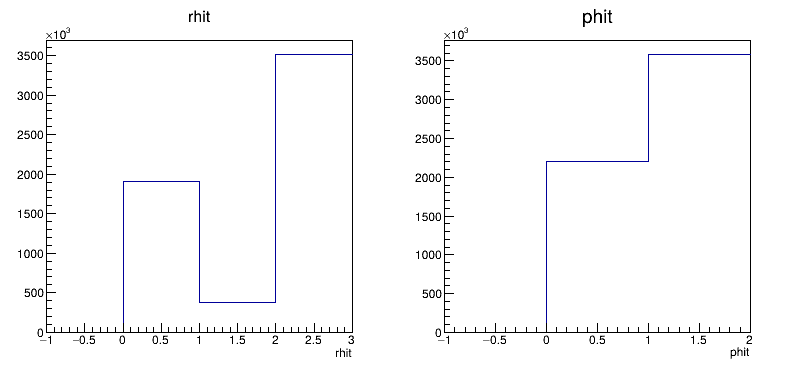

In [16]:
TCanvas *c2 = new TCanvas("c2","c2",800,400);
c2->Clear();
c2->Divide(2,1);
c2->cd(1);
tree->Draw("rhit");
c2->cd(2);
tree->Draw("phit");
gStyle->SetOptStat(0);
c2->Draw();


<h3 id="Ring-%E5%8F%8C%E5%87%BB%E4%BA%8B%E4%BB%B6">Ring 双击事件</h3><p>对于 <code>rhit==2</code> 的事件，可以直接画出两个 Ring hit 的条号关系：</p>
<ul>
<li>说明主要为相邻条事件</li>
</ul>


TCanvas::Constructor:0: RuntimeWarning: Deleting canvas with same name: c1

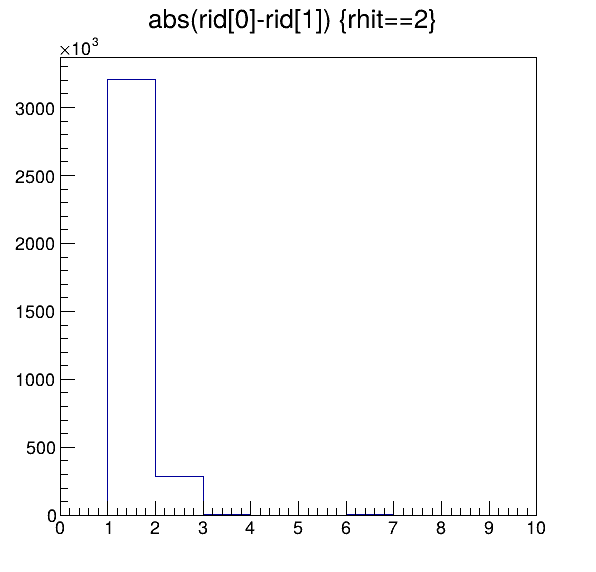

In [18]:
TCanvas *c1 =new TCanvas("c1","c1",600,600);
c1->Clear();
c1->Divide(1,1);
tree->Draw("abs(rid[0]-rid[1])>>(10,0,10)", "rhit==2", "colz");
c1->Draw();


<h4 id="%E7%9B%B8%E9%82%BB%E6%9D%A1%E8%83%BD%E9%87%8F%E5%85%B3%E8%81%94">相邻条能量关联</h4><ul>
<li>出现清楚的k=-1关联，主要对应相邻条能量共享(见3.3节)。</li>
</ul>


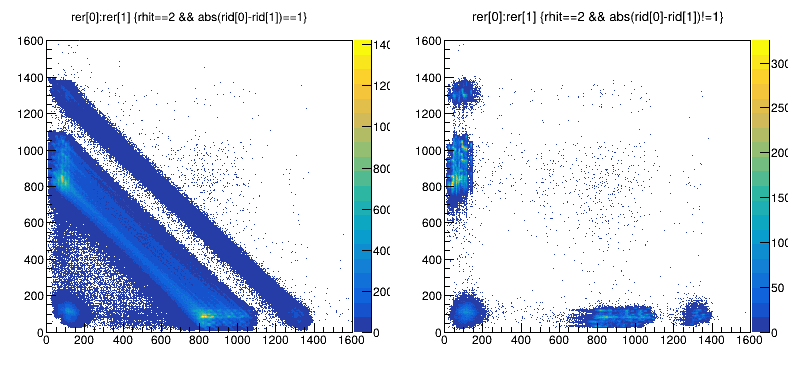

In [20]:
c2->Clear();
c2->Divide(2,1);
c2->cd(1);
tree->Draw("rer[0]:rer[1]>>h1(400,0,1600,400,0,1600)","rhit==2 && abs(rid[0]-rid[1])==1","colz");
c2->cd(2);
tree->Draw("rer[0]:rer[1]>>h2(400,0,1600,400,0,1600)","rhit==2 && abs(rid[0]-rid[1])!=1","colz");
c2->Draw();


<h4 id="ring%E7%9A%84%E7%9B%B8%E9%82%BB%E6%9D%A1%E8%83%BD%E9%87%8F%E4%B9%8B%E5%92%8C%E4%B8%8Epie%E7%9A%84%E8%83%BD%E9%87%8F%E5%85%B3%E8%81%94">ring的相邻条能量之和与pie的能量关联</h4><ul>
<li>出现k=1的关联(见3.4节)。</li>
</ul>


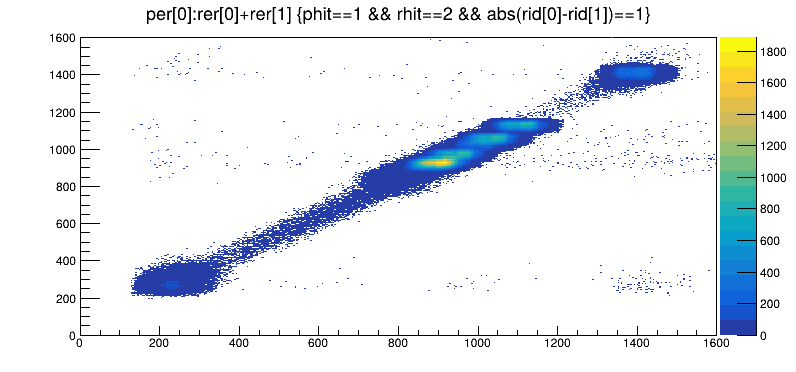

In [22]:
c2->Clear();
c2->Divide(1,1);
tree->Draw("per[0]:rer[0]+rer[1]>>(400,0,1600,400,0,1600)","phit==1 && rhit==2 && abs(rid[0]-rid[1])==1","colz");
c2->Draw();


<h4 id="%E9%80%89%E6%8B%A9%E7%89%B9%E5%AE%9A%E6%9D%A1%E4%B9%8B%E9%97%B4%E5%85%B3%E8%81%94">选择特定条之间关联</h4>


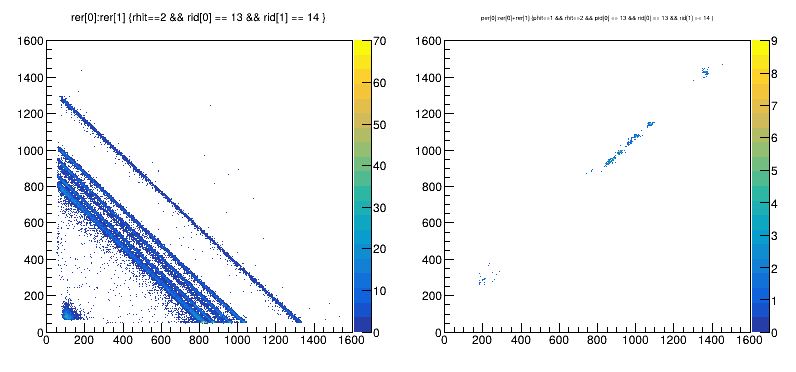

In [24]:
c2->Clear();
c2->Divide(2,1);
c2->cd(1);
tree->Draw("rer[0]:rer[1]>>h1(400,0,1600,400,0,1600)","rhit==2 && rid[0] == 13 && rid[1] == 14 ","colz");
c2->cd(2);
tree->Draw("per[0]:rer[0]+rer[1]>>(400,0,1600,400,0,1600)","phit==1 && rhit==2 && pid[0] == 13 && rid[0] == 13 && rid[1] == 14 ","colz");
c2->Draw();


<h3 id="%E8%A7%82%E5%AF%9Fpie%E5%92%8Cring%E7%9A%84%E6%89%80%E6%9C%89%E6%9D%A1%E7%9A%84%E8%83%BD%E9%87%8F%E5%88%86%E5%B8%83">观察pie和ring的所有条的能量分布</h3><p>利用 hit 结构可以非常方便地检查所有有效条的能量分布。通过这种方式，我们可以直接分析阈值特性、单条响应以及整体数据质量，而无需再回到原有的固定数组表示。</p>
<h4 id="%E8%83%BD%E9%87%8F%E6%9C%AA%E5%88%BB%E5%BA%A6">能量未刻度</h4>


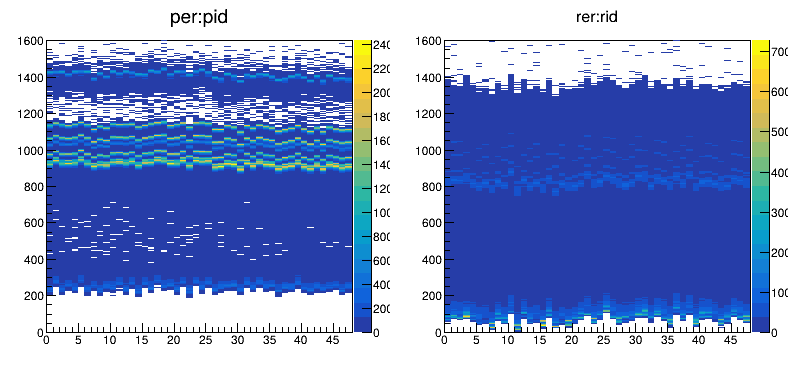

In [26]:
c2->Clear();
c2->Divide(2,1);
c2->cd(1);
tree->Draw("per:pid>>hh1(48,0,48,800,0,1600)","","colz");
c2->cd(2);
tree->Draw("rer:rid>>hh2(48,0,48,800,0,1600)","","colz");
c2->Draw();


<h4 id="%E8%83%BD%E9%87%8F%E5%B7%B2%E5%88%BB%E5%BA%A6">能量已刻度</h4>


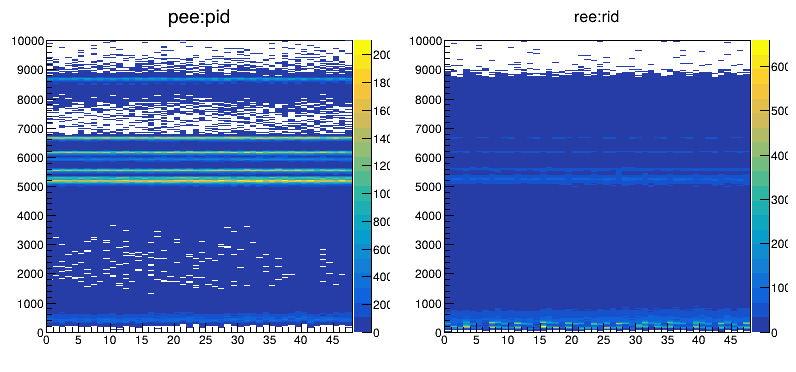

In [28]:
c2->Clear();
c2->Divide(2,1);
c2->cd(1);
tree->Draw("pee:pid>>ha1(48,0,48,800,0,10000)","","colz");
c2->cd(2);
tree->Draw("ree:rid>>ha2(48,0,48,800,0,10000)","","colz");
c2->Draw();


<h2 id="assignment">作业</h2><ol>
<li>参照 3.1 节完成 Pie 侧所有 48 条的能量刻度。结合已知谱线、峰序和残差检查峰匹配，再比较各条的峰宽和拟合质量。</li>
<li>将带有高斯拟合曲线的所有单条原始能谱、刻度后的单条能谱保存到一个 ROOT 文件中。将刻度后所有条的能谱累积在一个 TH1 上，给出 4 个参与刻度的 $\alpha$ 峰的分辨。</li>
<li>提取各条的分辨率，画出 FWHM-条id 的关系图并放在一个 <code>TGraph</code> 上（参照下图）。同时，对比刻度前后 Pie 侧所有条的能量分布。</li>
<li>将刻度前和刻度后的数据转换成 hit 结构，对比并展示刻度前后 Pie 侧所有条的整体能量分布情况。其中，Ring 侧的条事件需按照能量由大到小的顺序进行排序后，再填入 hit 结构。</li>
</ol>
<p><img alt="" src="fig/sigma.png"/></p>
<p>固定容量数组在每次 <code>Fill()</code> 前应满足 <code>0 ≤ phit,rhit ≤ 48</code>。示例文件的 <code>pee/ree</code> 单位为 keV，与 3.1 中的 MeV 相差 1000 倍。</p>